# Which segmentation model is best -- and does the technique change the answer?

There are two ways to get 3D masks out of a Cellpose-style model. **Stitched**
runs the 2D model per z-plane and links the masks through z by IoU
(`stitch_threshold`); **true 3D** segments the volume natively (`do_3D`). The
same model can behave very differently under the two, so a model ranking only
means something next to the technique that produced it.

A mask confined to one or two slices is usually not a cell -- it is a fragment
or a spurious detection, and your pipeline already throws these away with
`filter_params.min_z = 3`.

So the metric here is the **thin rate**: the share of masks occupying at most
`THIN_MAX_SLICES` z-slices. **Lower is better.** It reads directly as *the
fraction of detections the `min_z` filter discards* -- work the model did that
was thrown away.

This notebook scores every run under *both* technique trees and puts the models
side by side across them: same model, two techniques, adjacent.

**The volumes are never loaded into memory.** Each multi-page TIFF is opened as
a lazy zarr array whose chunks are the TIFF's own tiles, and the analysis
streams over those in chunk-aligned blocks -- so peak memory is set by the read
size, not the image size. Two backends do that (`READER`, below): `virtualizarr`
+ `virtual_tiff`, which can front an object store, and `tifffile`'s own
`aszarr` store, which is cheaper on local files. They agree exactly.

## Setup

Point `TECHNIQUE_ROOTS` at your own output trees -- one per segmentation
technique. The keys are the labels every figure uses, and their order is the
plotting order, so put the baseline first.

`LEVEL_NAMES` names the directory levels **below each technique root**; it
aligns to the *trailing* directories, so extra levels above become `level_0`,
`level_1`, .... `MODEL_LEVELS` then picks the levels that identify a
segmentation model, joined into a single `variant` label. Adjust both to your
layout -- if the model is only recorded in each run's `meta.json` rather than in
the path, read those into a column and name it here instead.

`READER` picks which backend fetches the bytes. Both stream sub-plane blocks and
both produce **identical** statistics; they differ in cost and in reach:

| | `tifffile` | `virtual` |
|---|---|---|
| open (per file) | ~1 ms | 17 ms small, ~325 ms on a 1750-chunk volume |
| read, 448 MB volume | 1.07 s | 1.35 s |
| peak memory | same | same |
| object store (`s3://`) | no | **yes** |
| persistable manifest | no | **yes** (Icechunk/Kerchunk) |

`"auto"` routes on the path, so leave it alone: local trees take the cheap path
today, and the day these roots become `s3://` URLs with a registry, the same
line switches to `virtual` on its own. The cell prints what it resolved to.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

from zspan import (
    BLUES,
    CATEGORICAL,
    add_variant_column,
    apply_theme,
    check_z_span,
    open_mask_volume,
    resolve_reader,
    scan_segmentations,
)
from zspan.plotting import GRID, INK, INK_MUTED, INK_SECONDARY, SURFACE

apply_theme()
pd.set_option("display.width", 160)

# One root per segmentation technique -- point these at your own output trees.
# The keys label every figure; their order is the plotting order.
TECHNIQUE_ROOTS = {
    "3D stitched": Path("data/segmentations_3d_stitched"),
    "true 3D": Path("data/segmentations_3d_true"),
}

LEVEL_NAMES = ("model", "region", "fov")   # levels below *each* technique root
MODEL_LEVELS = ["model"]                   # joined into a single `variant` label

# Which backend fetches the bytes.  "auto" routes on the path: local files go
# through tifffile, anything remote -- an s3:// URL, or a path handed an
# ObjectStoreRegistry -- goes through virtualizarr.  So this line does not have
# to change when the data moves to a bucket.  Pin it to "virtual" or "tifffile"
# to force one; the statistics are identical either way, only the cost differs,
# and only "virtual" can reach an object store.
READER = "auto"

# A mask this thin or thinner counts as a fragment.  Keep it in step with
# cellpose's `min_z`: min_z=3 discards anything under 3 slices, so 2 here.
THIN_MAX_SLICES = 2

# Technique is the comparison axis, so it owns the hue channel everywhere -- one
# fixed slot per technique, assigned once, so a colour never changes meaning
# between figures.  Model identity travels on position (A, B) and shape (D).
TECHNIQUE_COLOUR = dict(zip(TECHNIQUE_ROOTS, CATEGORICAL))

for name, root in TECHNIQUE_ROOTS.items():
    print(f"{name:14s} {str(root):42s} reader={resolve_reader(READER, root)!r}")

3D stitched    data/segmentations_3d_stitched             reader='tifffile'
true 3D        data/segmentations_3d_true                 reader='tifffile'


## Scan and score

One pass over each technique tree, then the thin rate per volume, per model and
per technique.

The last table is the coverage check: a side-by-side comparison is only a
comparison if both techniques ran the same models over the same FOVs, so the
counts in every row should match.

In [2]:
def scan_technique(name: str, root: Path):
    """Score every volume under one technique root, tagged with the technique."""
    result = scan_segmentations(
        root,
        pattern="**/masks.tif",
        level_names=LEVEL_NAMES,
        reader=READER,
        progress=lambda done, total, path: (
            print(f"  [{name}] scored {done}/{total} volumes")
            if done % max(1, total // 2) == 0 or done == total
            else None
        ),
    )
    for path, error in result.failures:
        print(f"  [{name}] FAILED to read {path}: {error!r}")
    return result.summary.assign(technique=name), result.labels.assign(technique=name)


scanned = [scan_technique(name, root) for name, root in TECHNIQUE_ROOTS.items()]
summary = pd.concat([part for part, _ in scanned], ignore_index=True)
labels = pd.concat([part for _, part in scanned], ignore_index=True)

summary = add_variant_column(summary, MODEL_LEVELS)
labels = add_variant_column(labels, MODEL_LEVELS)

# n_planes counts slices actually occupied, which is what a min_z filter tests.
# (It equals z_span unless a mask has a gap in z -- see n_with_z_gaps.)
labels["is_thin"] = labels["n_planes"] <= THIN_MAX_SLICES

# `relpath` is relative to its own technique root, so the two trees reuse the
# same values -- every join across them has to carry `technique` as well.
summary = summary.merge(
    labels.groupby(["technique", "relpath"])["is_thin"].mean().mul(100).rename("thin_rate"),
    on=["technique", "relpath"],
)

# Best first, averaged over both techniques, so a model holds one row position
# in every figure and the pair stays readable as a pair.
model_order = summary.groupby("variant")["thin_rate"].mean().sort_values().index.tolist()
technique_order = [t for t in TECHNIQUE_ROOTS if (summary["technique"] == t).any()]

if summary["n_z"].nunique() > 1:
    print(
        f"WARNING: stacks differ in depth {sorted(summary['n_z'].unique())}. "
        "A fixed slice threshold is not comparable across them -- consider a "
        "fraction of stack depth instead."
    )
if len(model_order) < 2:
    print(f"NOTE: only one model present ({model_order[0]}); comparisons need at least two.")
if len(technique_order) < 2:
    print(f"NOTE: only one technique present ({technique_order[0]}); nothing to compare across.")

# FOVs scored per model per technique.  Ragged rows mean part of any difference
# below is a difference in *what was scored*, not in the segmentation.
coverage = (
    summary.pivot_table(index="variant", columns="technique", values="relpath", aggfunc="count")
    .reindex(index=model_order, columns=technique_order)
)
if coverage.isna().to_numpy().any() or (coverage.nunique(axis=1) > 1).any():
    print("WARNING: the techniques did not cover the same FOVs -- see the counts below.")

print()
print(
    f"{len(summary)} volumes, {len(labels):,} masks, "
    f"{len(model_order)} model(s) x {len(technique_order)} technique(s)"
)
coverage.fillna(0).astype(int)

  [3D stitched] scored 207/414 volumes
  [3D stitched] scored 414/414 volumes
  [true 3D] scored 138/276 volumes
  [true 3D] scored 276/276 volumes

690 volumes, 601,742 masks, 2 model(s) x 2 technique(s)


technique,3D stitched,true 3D
variant,,
CBDN,198,132
VePo,216,144


## A. Which model wins, under which technique

Ranked by thin rate, best at the top. Each model gets one bar per technique,
adjacent, so a pair reads as a single comparison. Each dot is one FOV; the bar
is the mean.

The dots are the point. With only a handful of FOVs per model, **a gap smaller
than the within-model spread is not a result** -- if the dot clouds overlap, the
ranking is not yet decided and you need more FOVs, not a better plot. That goes
for the pairs too: two bars of different length whose dots interleave is not a
technique effect.

Rows are ordered on the mean over both techniques, which makes the thing worth
looking for **a pair that flips** -- a model that wins under one technique and
loses under the other. Scoring either tree on its own hides that completely.

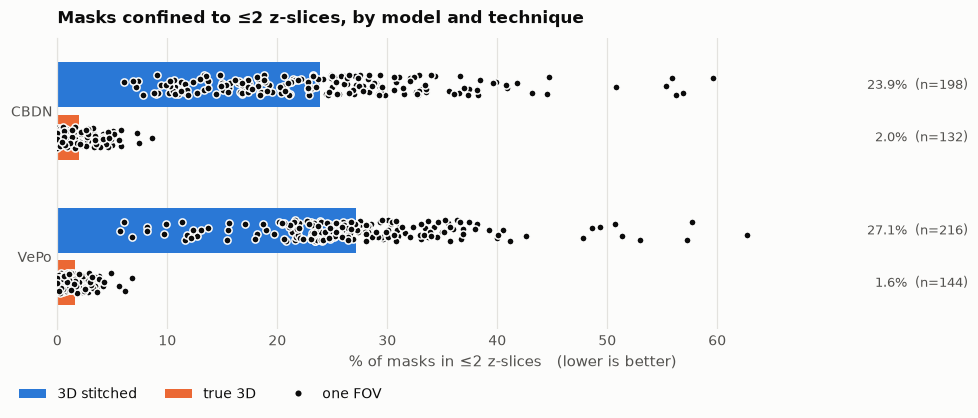

In [3]:
stats = summary.groupby(["variant", "technique"])["thin_rate"].agg(["mean", "size"])
means = stats["mean"].unstack("technique").reindex(index=model_order, columns=technique_order)
counts = stats["size"].unstack("technique").reindex(index=model_order, columns=technique_order)

positions = np.arange(len(model_order))
group_h = 0.72                            # row height shared by the techniques
bar_h = group_h / len(technique_order)

# Reserve a column on the right for the value labels, so they never sit on the
# marks.  The data range keeps the ticks; the reserved strip is not measurable.
data_max = float(summary["thin_rate"].max())
label_x = data_max * 1.32

fig, ax = plt.subplots(figsize=(9.0, 0.92 * len(model_order) + 2.0))
rng = np.random.default_rng(0)

for j, tech in enumerate(technique_order):
    offset = (j - (len(technique_order) - 1) / 2) * bar_h
    ax.barh(
        positions + offset, means[tech], height=bar_h * 0.86,
        color=TECHNIQUE_COLOUR[tech], zorder=2, label=tech,
    )
    for i, name in enumerate(model_order):
        points = summary.loc[
            (summary["variant"] == name) & (summary["technique"] == tech), "thin_rate"
        ].to_numpy(float)
        ax.scatter(
            points,
            i + offset + rng.uniform(-bar_h * 0.2, bar_h * 0.2, points.size),
            s=22, facecolor=INK, edgecolor=SURFACE,   # surface ring keeps
            linewidth=1.0, zorder=3,                  # overlapping dots apart
        )
        if np.isfinite(means.loc[name, tech]):
            ax.text(
                label_x, i + offset,
                f"{means.loc[name, tech]:.1f}%  (n={int(counts.loc[name, tech])})",
                va="center", ha="right", fontsize=8.5, color=INK_SECONDARY, zorder=4,
            )

ax.set_yticks(positions, model_order)
ax.set_ylim(len(model_order) - 0.5, -0.5)   # best model on top
ax.set_xlim(0, label_x)
ax.set_xticks([t for t in ax.get_xticks() if 0 <= t <= data_max])
ax.set_xlabel(f"% of masks in ≤{THIN_MAX_SLICES} z-slices   (lower is better)")
ax.set_title(
    f"Masks confined to ≤{THIN_MAX_SLICES} z-slices, by model and technique",
    pad=10, loc="left",
)
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.spines["left"].set_color(GRID)
ax.spines["bottom"].set_visible(False)

# Legend below the axes: the top-right corner is the value-label column and the
# bottom-right is the longest bar, so there is no free interior space.
handles, handle_labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], linestyle="", marker="o", markersize=5,
                      markerfacecolor=INK, markeredgecolor=SURFACE))
handle_labels.append("one FOV")
fig.legend(handles, handle_labels, loc="lower left", bbox_to_anchor=(0.012, 0.005),
           ncols=len(handles))
fig.tight_layout(rect=(0, 0.07, 1, 1))

## D. Is the win real, or just fewer detections?

A model can post a low thin rate simply by **not finding the faint cells** --
skip the marginal detections and the fragment tail disappears along with them.
Rate alone cannot tell "cleaner" from "more conservative". A technique can do
exactly the same thing.

So plot yield against quality. Each point is one FOV -- hue is the technique,
shape is the model -- and the ringed marker is that pair's centroid. **Better is
bottom-right**: many masks, few fragments. A model sitting bottom-*left* is
winning on the metric by doing less work.

The grey arrow is the technique effect for one model, running from its first
technique's centroid to its second. Read those first: an arrow that drops
straight down is a technique cleaning up fragments at no cost, while one that
drops by sliding left is paying for it in detections.

Check the x-range before reading a story into it -- a scatter auto-scales, so a
narrow yield spread gets stretched across the full width and can look like a
gradient when it is a couple of percent.

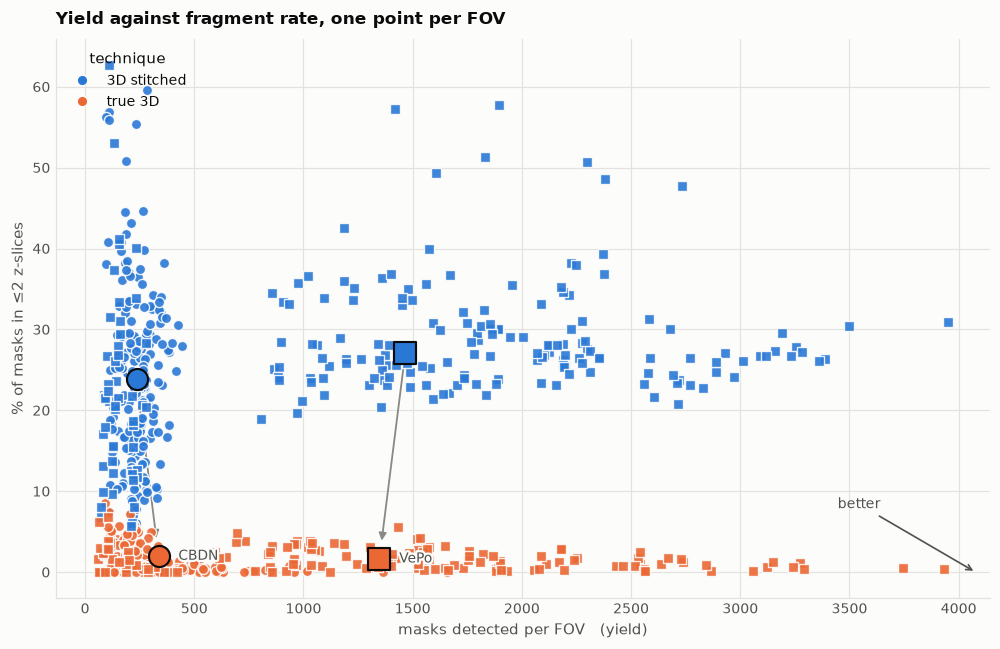

In [4]:
import matplotlib.patheffects as pe

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

fig, ax = plt.subplots(figsize=(9.2, 6.0))
for i, name in enumerate(model_order):
    # hue = technique, shape = model: the plot answers two questions at once, so
    # they get one channel each and neither has to be read off the other
    marker = MARKERS[i % len(MARKERS)]
    centroids = []
    for tech in technique_order:
        part = summary[(summary["variant"] == name) & (summary["technique"] == tech)]
        if part.empty:
            continue
        ax.scatter(
            part["n_labels"], part["thin_rate"],
            s=44, marker=marker, facecolor=TECHNIQUE_COLOUR[tech],
            edgecolor=SURFACE, linewidth=0.9, alpha=0.9, zorder=3,
        )
        centroids.append((part["n_labels"].mean(), part["thin_rate"].mean(), tech))

    # Neutral connector: it spans two hues, so it cannot take either of them.
    for (x0, y0, _), (x1, y1, _) in zip(centroids, centroids[1:]):
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0), zorder=2,
            arrowprops=dict(arrowstyle="-|>", color=INK_MUTED, lw=1.2,
                            shrinkA=10, shrinkB=12),
        )
    for x, y, tech in centroids:
        ax.scatter(x, y, s=190, marker=marker, facecolor=TECHNIQUE_COLOUR[tech],
                   edgecolor=INK, linewidth=1.4, zorder=4)
    if centroids:
        # Name the model on the arrowhead, so shape needs no second legend.  The
        # halo is load-bearing: a scatter has no free space to place a label in.
        ax.annotate(
            name, xy=centroids[-1][:2], xytext=(13, 0), textcoords="offset points",
            va="center", ha="left", fontsize=9, color=INK_SECONDARY, zorder=5,
            path_effects=[pe.withStroke(linewidth=3.0, foreground=SURFACE)],
        )

ax.set_xlabel("masks detected per FOV   (yield)")
ax.set_ylabel(f"% of masks in ≤{THIN_MAX_SLICES} z-slices")
ax.set_title("Yield against fragment rate, one point per FOV", pad=10, loc="left")
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.annotate(
    "better", xy=(0.985, 0.045), xytext=(0.86, 0.16), xycoords="axes fraction",
    textcoords="axes fraction", ha="center", fontsize=9, color=INK_SECONDARY,
    arrowprops=dict(arrowstyle="->", color=INK_SECONDARY, lw=1.1),
)
ax.legend(
    handles=[
        Line2D([], [], linestyle="", marker="o", markersize=7, label=tech,
               markerfacecolor=TECHNIQUE_COLOUR[tech], markeredgecolor=SURFACE)
        for tech in technique_order
    ],
    loc="upper left", ncols=1, title="technique",
)
fig.tight_layout()

## B. Where the difference lives

The thin rate is one number off a whole distribution. This is the distribution:
each row is a model's masks split by thickness, normalised to 100%, with one
panel per technique on identical axes.

Thickness is an **ordered** quantity, so it gets one hue light-to-dark rather
than a categorical set -- the fragments are the pale block at the left edge, and
"which model has fewest" is the width of that block. Rows keep the ranking from
A, so the two readings are perpendicular: **down** a panel is the model
comparison, **across** the panels on one row is the technique effect on that
model, with the model held fixed.

Watch the whole ramp, not just the pale end. A technique that shifts mass out of
the fragment block and into the *darkest* steps is not only cleaning up -- it is
also merging cells through z, which the thin rate cannot see.

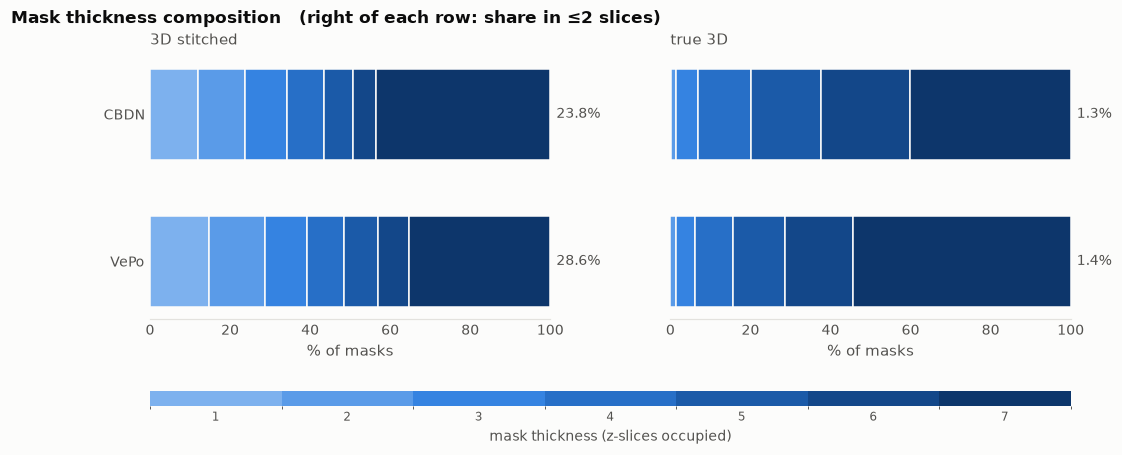

In [5]:
n_z = int(summary["n_z"].max())
thickness = np.arange(1, n_z + 1)

composition = (
    labels.groupby(["technique", "variant", "n_planes"]).size()
    .unstack("n_planes", fill_value=0)
    .reindex(columns=thickness, fill_value=0)
    .reindex(
        pd.MultiIndex.from_product([technique_order, model_order],
                                   names=["technique", "variant"]),
        fill_value=0,
    )
)
composition = 100 * composition.div(composition.sum(axis=1), axis=0).fillna(0.0)

# Start above the palest steps: an ordinal ramp must stay distinguishable from
# the page, unlike a continuous one where "near zero" may recede into it.
colours = BLUES(np.linspace(0.28, 1.0, len(thickness)))

fig, axes = plt.subplots(
    1, len(technique_order), sharex=True, sharey=True,
    figsize=(5.4 * len(technique_order), 0.62 * len(model_order) + 3.0),
    gridspec_kw={"wspace": 0.3},   # room for each panel's value column
)
axes = np.atleast_1d(axes)
positions = np.arange(len(model_order))

for ax, tech in zip(axes, technique_order):
    rows = composition.loc[tech]
    left = np.zeros(len(model_order))
    for j, n_slices in enumerate(thickness):
        widths = rows[n_slices].to_numpy()
        ax.barh(
            positions, widths, left=left, height=0.62, color=colours[j],
            edgecolor=SURFACE, linewidth=1.0, zorder=2,   # gap keeps segments apart
        )
        left += widths

    for i, name in enumerate(model_order):
        thin_pct = rows.loc[name, rows.columns <= THIN_MAX_SLICES].sum()
        ax.text(101.5, i, f"{thin_pct:.1f}%", va="center", ha="left",
                fontsize=9, color=INK_SECONDARY)

    ax.set_xlim(0, 100)
    ax.set_xlabel("% of masks")
    # Panel titles are subordinate to the figure title, and say so in weight.
    ax.set_title(tech, pad=8, loc="left", fontsize=10, fontweight="normal",
                 color=INK_SECONDARY)
    ax.tick_params(length=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

axes[0].set_yticks(positions, model_order)
axes[0].invert_yaxis()   # shared axis: best model on top in both panels, as in A
fig.suptitle(
    f"Mask thickness composition   (right of each row: share in ≤{THIN_MAX_SLICES} slices)",
    x=0.008, ha="left", fontsize=11, fontweight="bold", color=INK,
)

bar = fig.colorbar(
    mpl.cm.ScalarMappable(
        cmap=ListedColormap(colours),
        norm=BoundaryNorm(np.arange(0.5, len(thickness) + 1.5), len(thickness)),
    ),
    ax=list(axes), orientation="horizontal", ticks=thickness,
    fraction=0.07, pad=0.2, aspect=60,
)
bar.set_label("mask thickness (z-slices occupied)", color=INK_SECONDARY, fontsize=9)
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=8)

### The numbers

Shipped next to the figures on purpose: some palette steps sit below 3:1
contrast on a light background, so the table is what keeps the comparison
readable for everyone.

The first table is the paired readout -- one row per model, one column per
technique, and Δ for what the switch did to it. Negative means the second
technique produced fewer fragments.

`n_with_z_gaps` counts masks whose bounding box spans more slices than they
occupy -- a mask that appears, disappears and returns. Those are stitching
errors rather than fragments, and they inflate `z_span` without inflating
`n_planes`, which is why the thin rate is computed on `n_planes`. Expect them
concentrated in the stitched tree; a true-3D run producing them is a different
bug and worth chasing separately.

In [ ]:
from IPython.display import display

model_table = (
    summary.groupby(["variant", "technique"])
    .agg(
        fovs=("n_labels", "size"),
        masks=("n_labels", "sum"),
        masks_per_fov=("n_labels", "mean"),
        thin_rate=("thin_rate", "mean"),
        thin_rate_min=("thin_rate", "min"),
        thin_rate_max=("thin_rate", "max"),
        mean_z_span=("mean_z_span", "mean"),
        with_z_gaps=("n_with_z_gaps", "sum"),
    )
    .reindex(pd.MultiIndex.from_product([model_order, technique_order],
                                        names=["variant", "technique"]))
    .round(2)
)

paired = model_table["thin_rate"].unstack("technique").reindex(columns=technique_order)
if len(technique_order) == 2:
    first, last = technique_order
    paired[f"Δ ({last} − {first})"] = paired[last] - paired[first]

display(paired.round(2))
model_table

## Looking at one volume

The worst FOV across both trees. `open_mask_volume` gives a lazy `(z, y, x)`
handle. `chunks` reports the TIFF's own tile or strip geometry; reads are
batched to `target_bytes` on top of that, because one chunk per read is
dominated by zarr's per-request overhead.

In [ ]:
worst_row = summary.nlargest(1, "thin_rate").iloc[0]
worst = Path(worst_row["path"])
volume = open_mask_volume(worst, reader=READER)

print(f"{worst_row['variant']} under {worst_row['technique']}: {worst_row['relpath']}")
print(volume)
print(f"  native chunk {volume.chunks} -> batched read {volume.read_block_shape()}")
print(f"  full volume would be {volume.nbytes / 1e6:.1f} MB in memory")

z_table = check_z_span(volume)
fragments = z_table[z_table["n_planes"] <= THIN_MAX_SLICES]
print(f"  {len(fragments)} of {len(z_table)} masks are fragments "
      f"({100 * len(fragments) / len(z_table):.1f}%)")
fragments.head()

### Memory: streamed vs. loaded

Same statistics both ways. The streamed peak scales with the read size, not the
volume, so the gap widens linearly as images grow.

In [ ]:
import tracemalloc

import tifffile

tracemalloc.start()
lazy_table = check_z_span(open_mask_volume(worst, reader=READER))
_, lazy_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
eager_table = check_z_span(tifffile.imread(worst))
_, eager_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

assert lazy_table.equals(eager_table), "streaming must not change the answer"
print(f"streamed : {lazy_peak / 1e6:7.2f} MB peak   (reader={volume.backend!r})")
print(f"loaded   : {eager_peak / 1e6:7.2f} MB peak   ({eager_peak / lazy_peak:.0f}x more)")

## Scaling to bigger images

**Chunking is already in place.** `check_z_span` folds one block at a time into
label-indexed `min`/`max` arrays. Because min/max are associative, block order
is irrelevant and the result is identical to the in-memory
`scipy.ndimage.find_objects` version -- `tests/test_zspan.py` asserts exactly
that, under both readers. Memory is `O(max_label)`, independent of image size.

**Read size is the lever, not thread count.** Every block read crosses zarr's
sync-to-async bridge at roughly a millisecond a call, so one chunk per read
makes that overhead the whole runtime. Measured on 7x4000x4000 uint32 striped
TIFFs, anything from 2 to 32 MiB ties within noise, while the native 16-row
strip costs ~2.8x and a whole-plane read costs ~1.3x. Going *bigger* than 8 MiB
is not free either -- time stays flat while peak memory grows linearly (21 MB at
2 MiB, 90 MB at 32, 165 MB at 64), which spends the only thing streaming buys:

```python
from zspan import tune_read_size, best_read_size

table = tune_read_size("region_X/fov_01/masks.tif", reader=READER)
scan_segmentations(root, target_bytes=best_read_size(table), reader=READER)
```

Tune with the reader you will scan with -- the block sizes are identical, but
the per-read overhead the curve measures is not.

Threads help far less -- zarr funnels every chunk request through one event
loop, so workers contend on it (~1.1x from 1 to 4).

**Remote data** is what `reader="virtual"` is for. It needs a store, not
different code, and `"auto"` will route to it on its own once the path is a URL:

```python
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

registry = ObjectStoreRegistry({"s3://bucket/segs": S3Store("bucket")})
volume = open_mask_volume("s3://bucket/segs/.../masks.tif", registry)
```

**Persist the manifests** with `virtualizarr`'s Icechunk/Kerchunk writers if you
rescan often, and later passes skip TIFF header parsing entirely -- which is
where the virtual backend's per-file open cost goes to zero and it wins outright.

## Hand-off to napari

`to_xarray()` returns a lazy dask-backed `DataArray`, so napari pulls only the
planes it displays.

```python
import napari

viewer = napari.Viewer()
viewer.add_labels(volume.to_xarray().data, name=worst.parent.name)
```